## Set up the environment

In [22]:
!pip install -q xgboost lightgbm imbalanced-learn kaggle shap


In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
import json
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42


## Get the dataset


In [24]:


CSV_PATH = "creditcard.csv"
df = pd.read_csv(CSV_PATH)
df


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65448,51589,-0.248790,1.080973,-0.917017,-0.976831,3.234594,2.963384,0.673578,0.509785,-0.674202,...,-0.160001,-0.482385,-0.326914,0.885378,0.220774,0.300600,-0.277872,-0.146796,0.76,0.0
65449,51589,1.130476,0.090195,0.358313,0.579876,-0.413699,-0.873547,0.192253,-0.105390,-0.005114,...,-0.438925,-1.421174,0.310895,0.353704,-0.083121,-0.015829,-0.046818,0.021914,42.90,0.0
65450,51590,1.298511,0.103767,0.026676,0.239810,0.066831,-0.021495,-0.125705,0.066416,-0.000780,...,-0.292495,-0.919318,-0.009714,-0.866837,0.313025,0.152421,-0.040222,-0.004856,1.98,0.0
65451,51591,-1.062891,0.242080,2.425183,1.125829,-1.284732,1.535764,-0.524604,1.074866,0.627453,...,0.194731,0.719323,0.072734,0.042001,0.060638,-0.254387,0.012123,0.010512,113.65,0.0


## Data Inspection


In [25]:
df.shape


(65453, 31)

In [26]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65453 entries, 0 to 65452
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    65453 non-null  int64  
 1   V1      65453 non-null  float64
 2   V2      65453 non-null  float64
 3   V3      65453 non-null  float64
 4   V4      65453 non-null  float64
 5   V5      65453 non-null  float64
 6   V6      65453 non-null  float64
 7   V7      65453 non-null  float64
 8   V8      65453 non-null  float64
 9   V9      65453 non-null  float64
 10  V10     65453 non-null  float64
 11  V11     65452 non-null  float64
 12  V12     65452 non-null  float64
 13  V13     65452 non-null  float64
 14  V14     65452 non-null  float64
 15  V15     65452 non-null  float64
 16  V16     65452 non-null  float64
 17  V17     65452 non-null  float64
 18  V18     65452 non-null  float64
 19  V19     65452 non-null  float64
 20  V20     65452 non-null  float64
 21  V21     65452 non-null  float64
 22

In [27]:
df.head(20)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
5,2,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0.0
6,4,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0.0
7,7,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0.0
8,7,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0.0
9,9,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0.0


In [28]:
df.tail(20)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
65433,51581,-0.218412,-0.155648,1.439698,-1.683591,-0.484922,0.026415,0.026987,-0.098996,2.089117,...,0.174932,1.053827,-0.339238,-0.393212,-0.128057,-0.392818,-0.026085,-0.063133,30.24,0.0
65434,51582,-1.181879,-0.626014,1.402737,-2.269635,-1.490914,-1.123785,-0.706188,0.473447,-2.130448,...,-0.233011,-0.752334,0.214031,0.257252,-0.186320,-0.544342,0.204117,0.044390,75.00,0.0
65435,51583,-0.592419,0.581105,1.761699,-0.224955,0.296722,-1.019249,0.531564,-0.019708,-0.501161,...,-0.098909,-0.402724,0.122541,0.596412,-0.245804,-0.058492,-0.024243,0.013814,1.29,0.0
65436,51583,0.076732,-0.037096,-0.140768,-0.335914,1.192665,4.808826,-2.246547,-1.559116,-0.961004,...,-1.772285,-0.462482,-0.099099,0.982049,1.014879,-0.151085,0.165979,0.243065,16.95,0.0
65437,51583,-1.619568,0.044393,1.613021,1.205095,-0.405996,0.678456,0.082310,0.579691,0.148207,...,0.110185,0.578867,-0.130359,0.041866,0.031523,-0.230559,0.032891,-0.139276,126.33,0.0
65438,51583,-0.686502,1.137505,1.572096,0.006761,-0.346155,-1.120985,0.659832,-0.037378,-0.111647,...,-0.246214,-0.619761,0.042031,0.668500,-0.210655,0.058382,0.370302,0.184229,9.84,0.0
65439,51584,1.236445,-0.161662,0.616486,-0.085567,-0.717561,-0.428120,-0.453537,0.099592,0.291006,...,-0.173456,-0.599937,0.110651,0.016743,-0.008708,0.794336,-0.073363,-0.000179,8.07,0.0
65440,51584,-0.545224,-0.737111,0.285134,-2.529096,1.669126,3.355060,-1.131631,0.829155,-2.742263,...,-0.183310,-0.382332,-0.181071,0.990904,0.351203,-0.021601,-0.064378,0.142925,10.00,0.0
65441,51584,1.259327,0.518322,-0.581743,0.644250,0.244393,-0.907029,0.265024,-0.131680,-0.348788,...,-0.111525,-0.315321,-0.128312,-0.092178,0.574333,0.372626,-0.040279,0.022472,0.76,0.0
65442,51585,1.113605,-0.172011,0.379212,0.506943,-0.645561,-0.630565,-0.147507,-0.007131,0.080059,...,0.205311,0.445383,-0.168938,0.381539,0.454550,0.602659,-0.058455,0.007332,59.74,0.0


In [29]:
print("Number of fully duplicated rows:", df.duplicated().sum())


Number of fully duplicated rows: 260


In [30]:
df.nunique()


,0
Time,31542
V1,64044
V2,64044
V3,64044
V4,64044
V5,64044
V6,64044
V7,64044
V8,64044
V9,64044


In [31]:
df.isnull().sum() # Missing values


,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [32]:
# Remove rows with missing target labels
df = df.dropna(subset=["Class"]).copy()

print("NaN in Class after cleaning:", df["Class"].isna().sum())

NaN in Class after cleaning: 0


In [33]:
class_pct = (df.groupby("Class")[["Amount"]].count() / df.shape[0]) * 100 #Percentage calculation
class_pct.columns = ["Percentage"]
class_pct.index = ["Genuine (0)", "Fraud (1)"]
class_pct


,Percentage
Genuine (0),99.741796
Fraud (1),0.258204


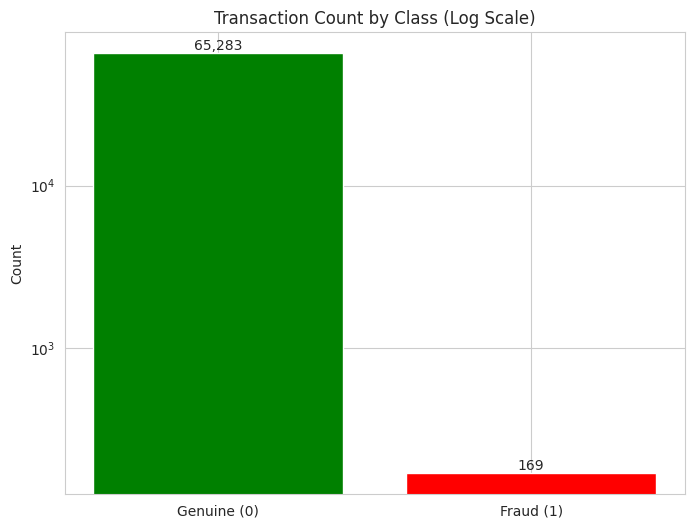

In [34]:
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8,6))

bars = ax.bar(
    ["Genuine (0)", "Fraud (1)"],
    [class_counts[0], class_counts[1]],
    color=["green", "red"]
)

for bar in bars:
    ax.annotate(
        f"{int(bar.get_height()):,}",
        (bar.get_x() + bar.get_width()/2, bar.get_height()),
        ha="center",
        va="bottom"
    )

ax.set_yscale("log")
ax.set_title("Transaction Count by Class (Log Scale)")
ax.set_ylabel("Count")

plt.show()

## Explore the data further (EDA)

In [35]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,65452.0,33429.569394,14078.097455,0.000000,27747.500000,36941.000000,43905.250000,51591.000000
V1,65452.0,-0.240598,1.857133,-56.407510,-1.000865,-0.243515,1.153815,1.960497
V2,65452.0,-0.012993,1.649818,-72.715728,-0.585928,0.074997,0.730518,18.183626
V3,65452.0,0.684081,1.426723,-32.965346,0.197947,0.774185,1.408082,4.226108
V4,65452.0,0.171716,1.378748,-5.172595,-0.723651,0.189236,1.054620,16.715537
V5,65452.0,-0.266845,1.388865,-42.147898,-0.884710,-0.298681,0.272822,34.801666
V6,65452.0,0.103228,1.306452,-26.160506,-0.636487,-0.148812,0.495141,22.529298
V7,65452.0,-0.113172,1.254947,-31.764946,-0.602982,-0.073051,0.422142,36.677268
V8,65452.0,0.059440,1.223340,-73.216718,-0.142512,0.065170,0.342671,20.007208
V9,65452.0,0.037198,1.170964,-9.283925,-0.662886,-0.057662,0.695867,10.392889


### Distribution of Amount and Time by class

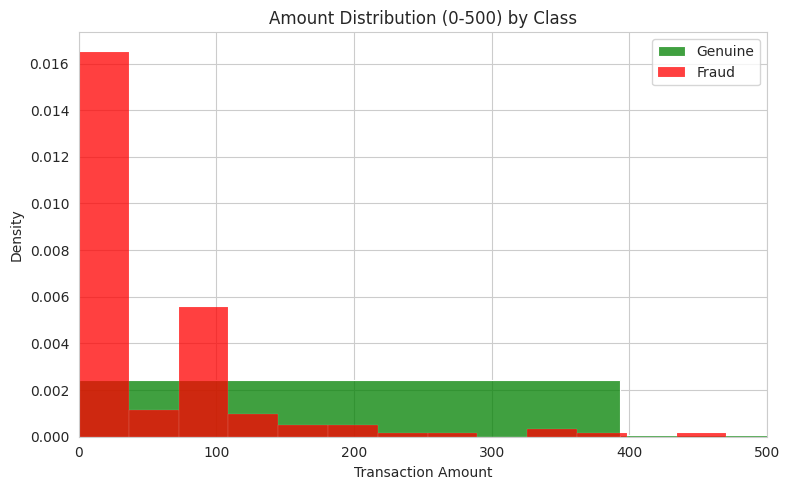

In [36]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df[df["Class"] == 0]["Amount"],
    bins=50,
    color="green",
    label="Genuine",
    stat="density"
)

sns.histplot(
    df[df["Class"] == 1]["Amount"],
    bins=50,
    color="red",
    label="Fraud",
    stat="density"
)

plt.xlim(0, 500)
plt.title("Amount Distribution (0-500) by Class")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()

# Save ONLY the histogram
plt.savefig(
    "amount_distribution_0_500_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Transaction Count by Hour of Day

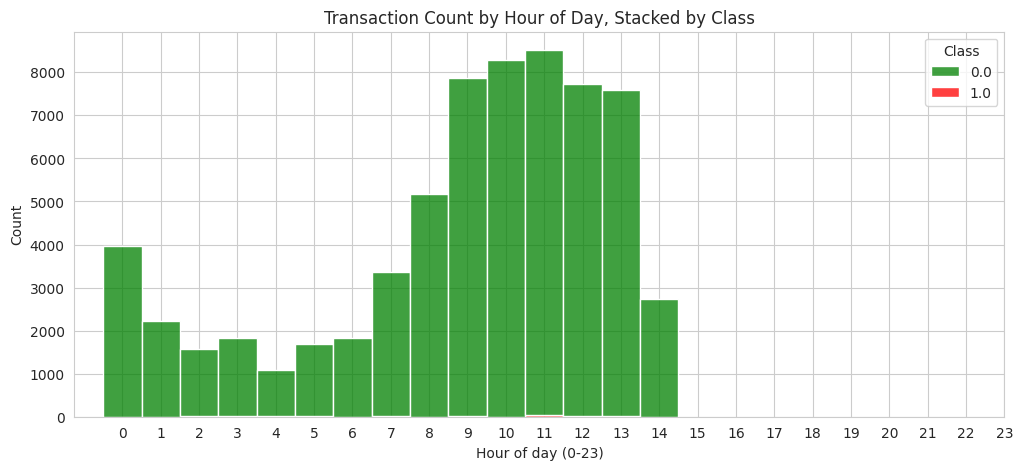

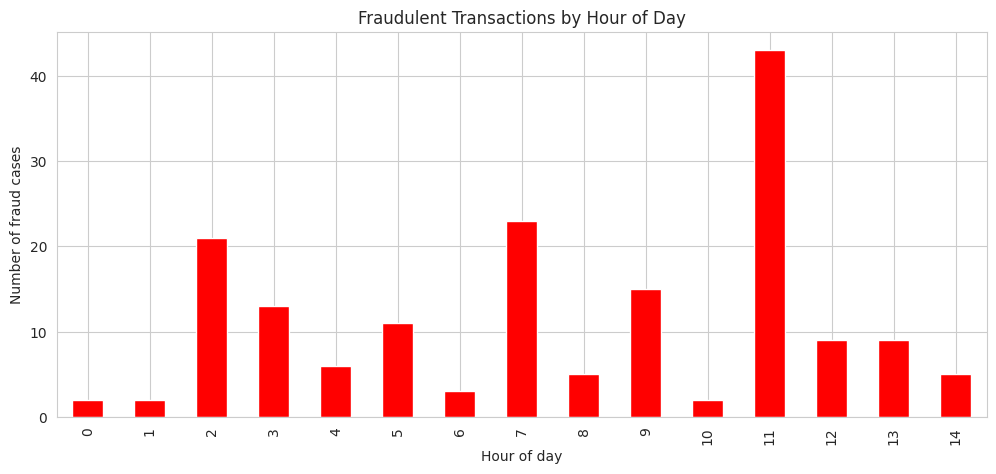

In [37]:
df["Hour"] = (df["Time"] // 3600) % 24

plt.figure(figsize=(12, 5))
sns.histplot(data=df, x="Hour", hue="Class", multiple="stack", bins=24,
             palette=["green", "red"], discrete=True)
plt.title("Transaction Count by Hour of Day, Stacked by Class")
plt.xlabel("Hour of day (0-23)")
plt.xticks(range(0, 24))
plt.show()

fraud_by_hour = df[df["Class"] == 1].groupby("Hour")["Class"].count()
plt.figure(figsize=(12, 5))
fraud_by_hour.plot(kind="bar", color="red")
plt.title("Fraudulent Transactions by Hour of Day")
plt.xlabel("Hour of day")
plt.ylabel("Number of fraud cases")
plt.show()


### Correlation heatmap

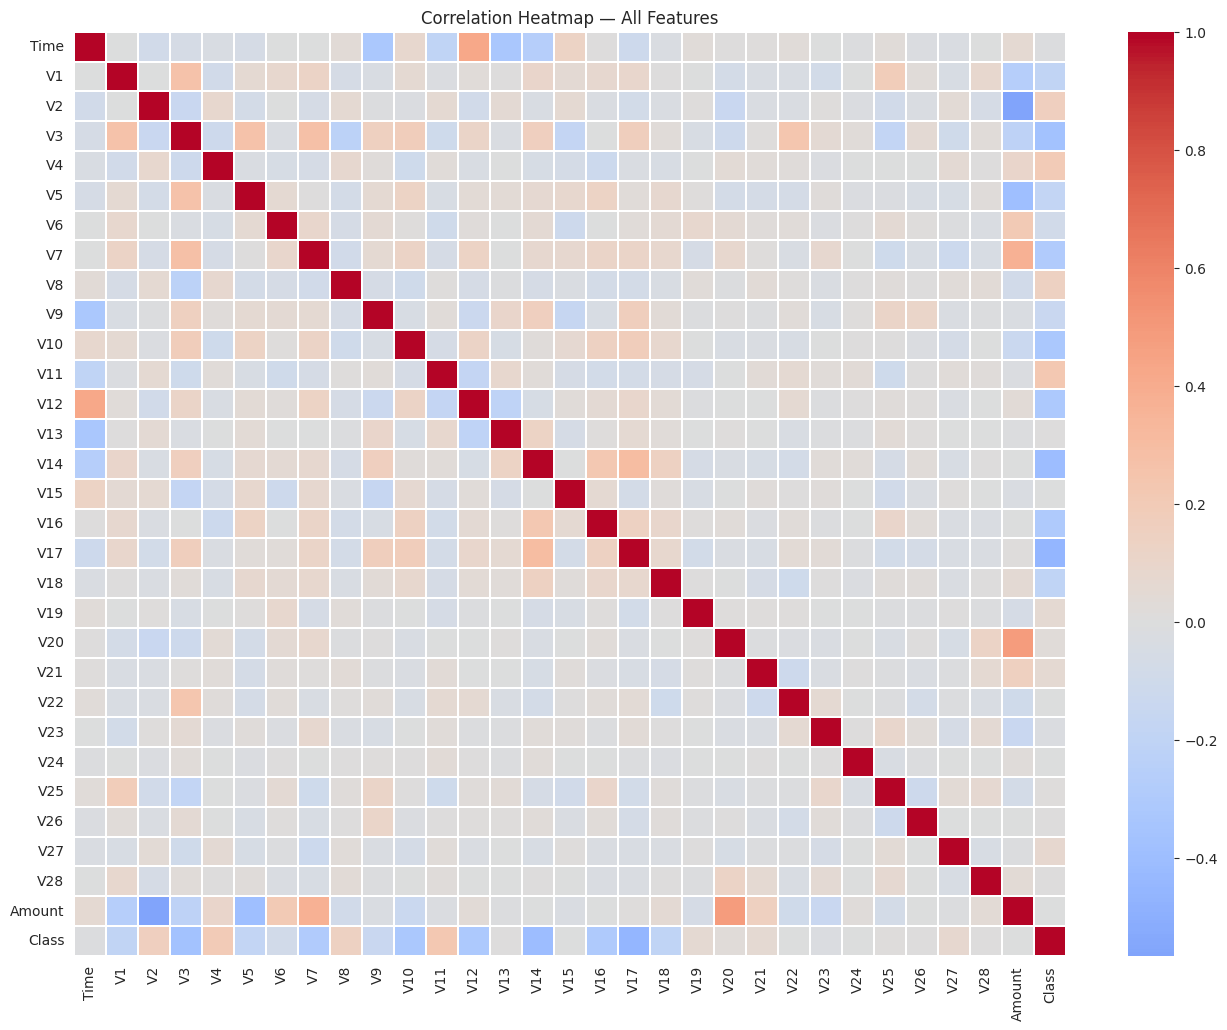

In [38]:
plt.figure(figsize=(16, 12))
corr = df.drop(columns=["Hour"]).corr()
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Correlation Heatmap — All Features")
plt.show()


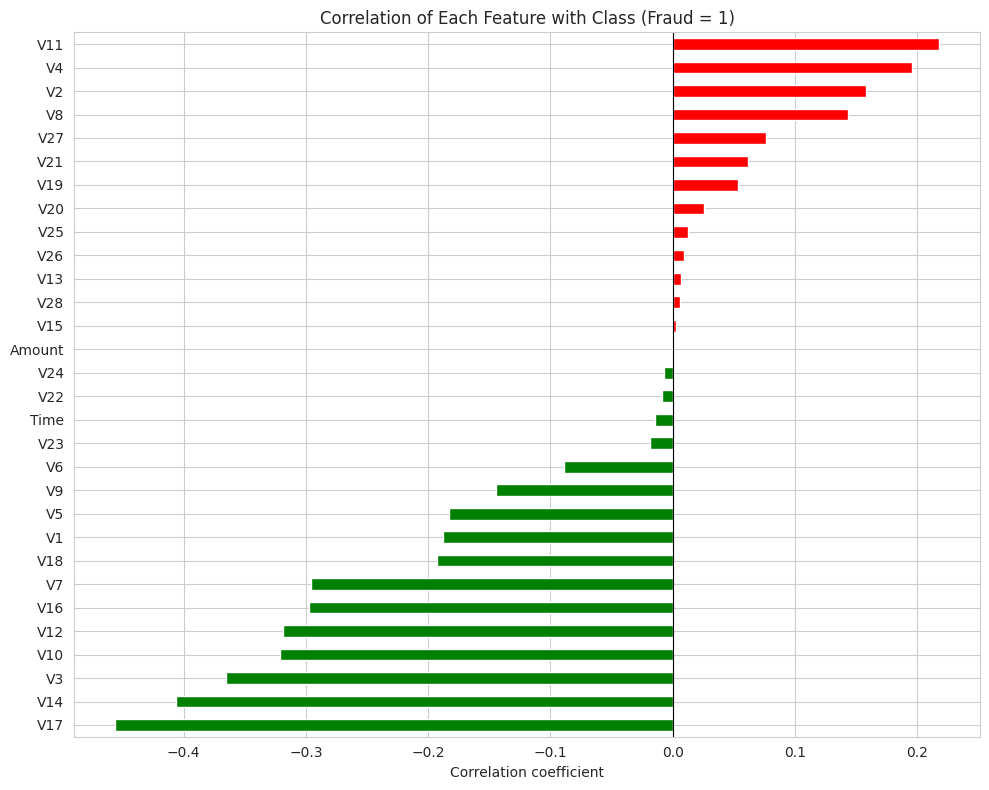

Top features correlated with fraud: ['V17', 'V14', 'V3', 'V10']


In [39]:

# Correlation of each feature with Class
class_corr = corr["Class"].drop("Class").sort_values()

plt.figure(figsize=(10, 8))

# Red = positive correlation with fraud
# Green = negative correlation with fraud
colors = np.where(class_corr > 0, "red", "green")

class_corr.plot(
    kind="barh",
    color=colors
)

plt.title("Correlation of Each Feature with Class (Fraud = 1)")
plt.xlabel("Correlation coefficient")

plt.axvline(0, color="black", linewidth=0.8)

plt.tight_layout()
plt.show()

# Top features by absolute correlation
top_features = (
    class_corr.abs()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

print("Top features correlated with fraud:", top_features)


### Pairwise relationships of the top fraud-correlated features


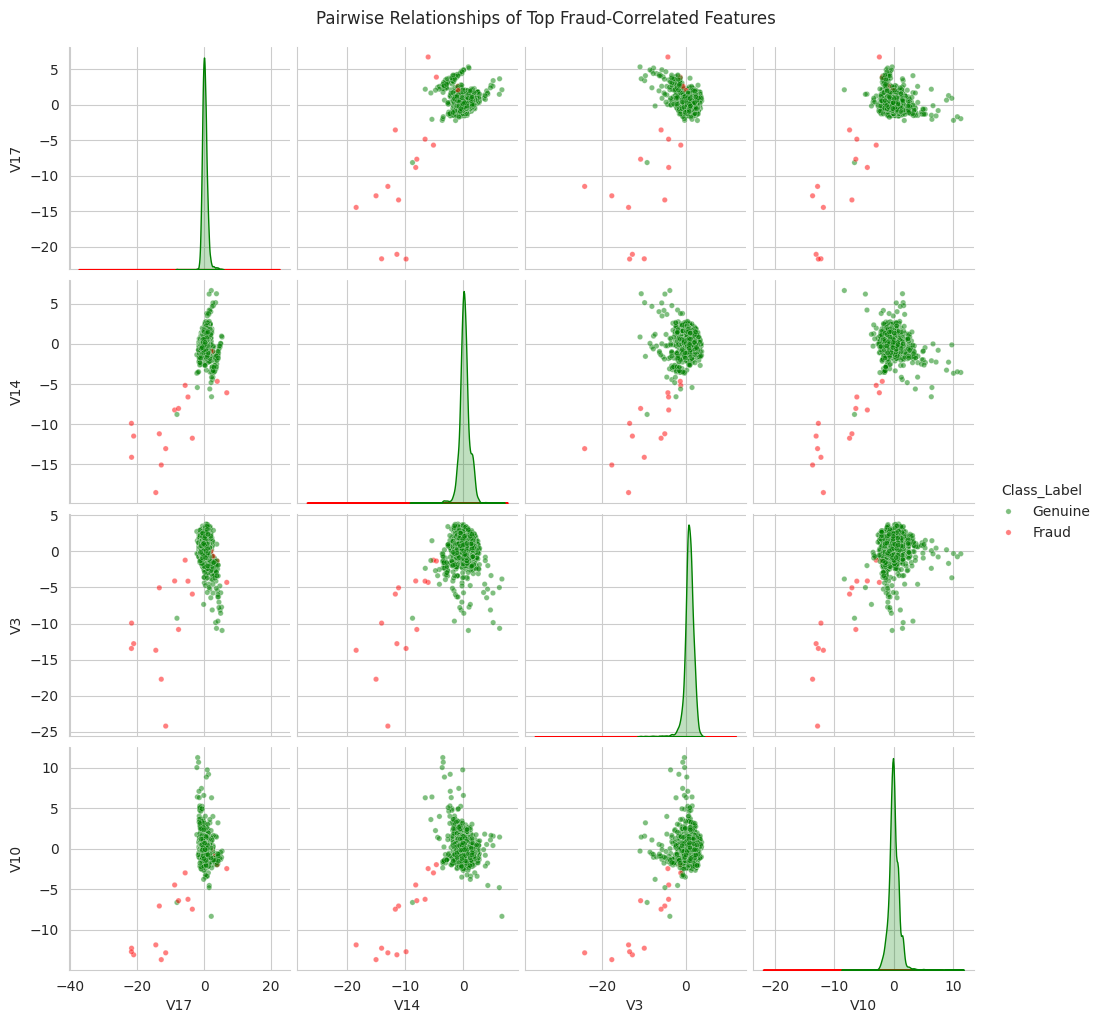

In [40]:
sample_df = df.sample(5000, random_state=RANDOM_STATE).copy()

sample_df["Class_Label"] = sample_df["Class"].map({
    0: "Genuine",
    1: "Fraud"
})

sns.pairplot(
    sample_df,
    vars=top_features,
    hue="Class_Label",
    palette={
        "Genuine": "green",
        "Fraud": "red"
    },
    plot_kws={
        "alpha": 0.5,
        "s": 15
    }
)

plt.suptitle(
    "Pairwise Relationships of Top Fraud-Correlated Features",
    y=1.02
)

plt.show()

### Skewness check

Top 10 most skewed features:

Amount    16.488060
V28       14.296069
V20        4.555566
V21        2.599564
V6         1.047018
V26        0.686453
V11        0.608070
V9         0.544979
V4         0.421058
V13        0.151497
dtype: float64


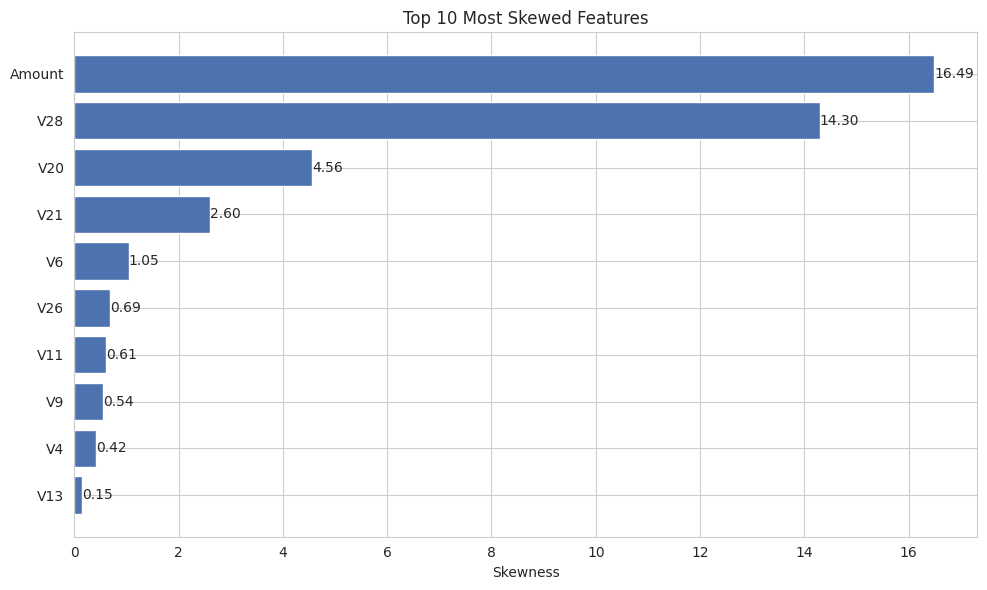

In [41]:


# Select only numeric features and exclude target/non-feature columns
skew_vals = (
    df.select_dtypes(include="number")
      .drop(columns=["Class"], errors="ignore")
      .drop(columns=["Hour"], errors="ignore")
      .skew()
      .sort_values(ascending=False)
)

print("Top 10 most skewed features:\n")
print(skew_vals.head(10))

plt.figure(figsize=(10, 6))

bars = plt.barh(
    skew_vals.head(10).index[::-1],
    skew_vals.head(10).values[::-1],
    color="#4C72B0"
)

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y() + bar.get_height()/2,
        f"{bar.get_width():.2f}",
        va="center"
    )

plt.title("Top 10 Most Skewed Features")
plt.xlabel("Skewness")

plt.tight_layout()
plt.show()

## Preprocess the data


In [42]:

scaler = StandardScaler()

df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])

amount_scaler = StandardScaler()
df["Amount_scaled"] = amount_scaler.fit_transform(df[["Amount"]])

time_scaler = StandardScaler()
df["Time_scaled"] = time_scaler.fit_transform(df[["Time"]])

# Remove target and non-feature columns
feature_cols = [
    c for c in df.columns
    if c not in ["Class", "Class_label", "Amount", "Time", "Hour"]
]

X = df[feature_cols]
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Fraud in train:", y_train.sum())
print("Test shape :", X_test.shape, " Fraud in test :", y_test.sum())

Train shape: (52361, 30)  Fraud in train: 135.0
Test shape : (13091, 30)  Fraud in test : 34.0


## Handle class imbalance with SMOTE


Before SMOTE: {0.0: 52226, 1.0: 135}
After SMOTE : {0.0: 52226, 1.0: 52226}


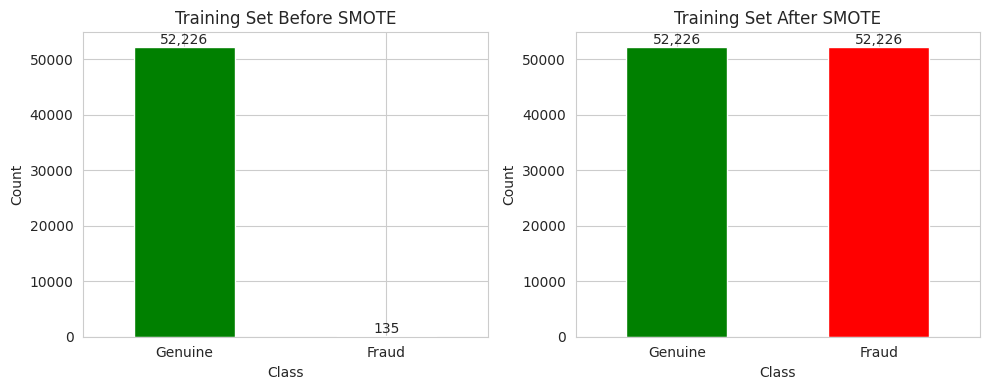

In [43]:
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

print("Before SMOTE:", y_train.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)

X_train_res, y_train_res = smote.fit_resample(
    X_train,
    y_train
)

print("After SMOTE :", y_train_res.value_counts().to_dict())


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
before_counts = y_train.value_counts().sort_index()

before_counts.plot(
    kind="bar",
    ax=axes[0],
    color=["green", "red"]
)

axes[0].set_title("Training Set Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels(["Genuine", "Fraud"], rotation=0)


# After SMOTE
after_counts = y_train_res.value_counts().sort_index()

after_counts.plot(
    kind="bar",
    ax=axes[1],
    color=["green", "red"]
)

axes[1].set_title("Training Set After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels(["Genuine", "Fraud"], rotation=0)


# Add values on bars
for ax in axes:
    for bar in ax.patches:
        ax.annotate(
            f"{int(bar.get_height()):,}",
            (bar.get_x() + bar.get_width()/2, bar.get_height()),
            ha="center",
            va="bottom",
            fontsize=10
        )

plt.tight_layout()
plt.show()

## Train the three proposal models  **Random Forest**, **XGBoost**, and **LightGBM**


In [44]:


results = {}
fitted_models = {}
roc_data = {}
pr_data = {}


def evaluate_model(name, model, X_test, y_test):

    y_pred = model.predict(X_test)

    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)


    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)

    metrics = {
        "Accuracy": accuracy,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
    }

    results[name] = metrics


    print(f"--- {name} ---")
    print("Accuracy:", round(accuracy, 4))
    print("ROC AUC:", round(roc_auc, 4))

    print("\nClassification Report:\n")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["Genuine", "Fraud"]
        )
    )


    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Genuine", "Fraud"]
    )

    disp.plot(cmap="Blues")

    plt.title(f"{name} — Confusion Matrix")
    plt.grid(False)
    plt.show()


    # ROC Curve
    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    roc_data[name] = (
        fpr,
        tpr,
        roc_auc
    )


    plt.figure(figsize=(7, 6))

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})",
        color="#4C72B0"
    )

    plt.plot(
        [0, 1],
        [0, 1],
        "k--"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{name} - ROC Curve")
    plt.legend()
    plt.grid(True)

    plt.show()


    # Precision-Recall data
    precision, recall, _ = precision_recall_curve(
        y_test,
        y_prob
    )

    pr_data[name] = (
        precision,
        recall,
        pr_auc
    )


    return y_prob



def plot_top_features(name, model, feature_names, top_n=5):

    importances = model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })


    importance_df = importance_df.sort_values(
        by="Importance",
        ascending=False
    )


    top = importance_df.head(top_n).sort_values(
        by="Importance"
    )


    plt.figure(figsize=(10, 5))


    plt.barh(
        top["Feature"],
        top["Importance"],
        color="#4C72B0"
    )


    plt.xlabel("Feature Importance")
    plt.title(
        f"Top {top_n} Important Features - {name}"
    )


    plt.tight_layout()
    plt.show()


    return importance_df

--- Random Forest ---
Accuracy: 0.9995
ROC AUC: 0.9826

Classification Report:

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     13057
       Fraud       0.89      0.91      0.90        34

    accuracy                           1.00     13091
   macro avg       0.94      0.96      0.95     13091
weighted avg       1.00      1.00      1.00     13091



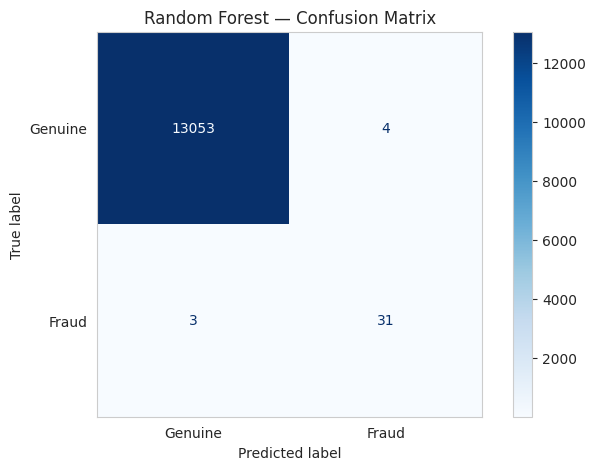

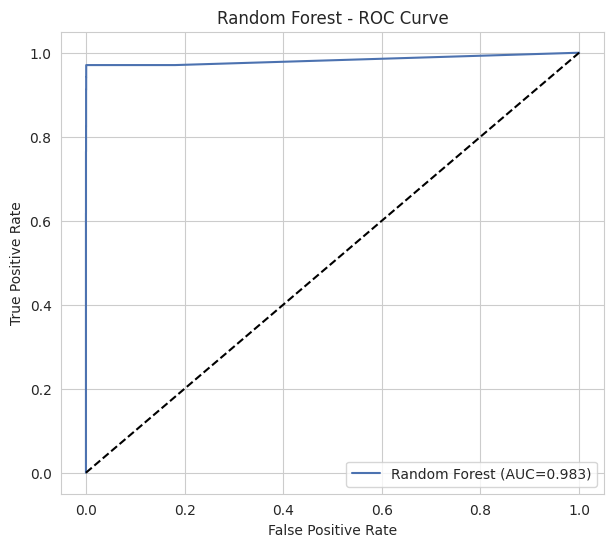

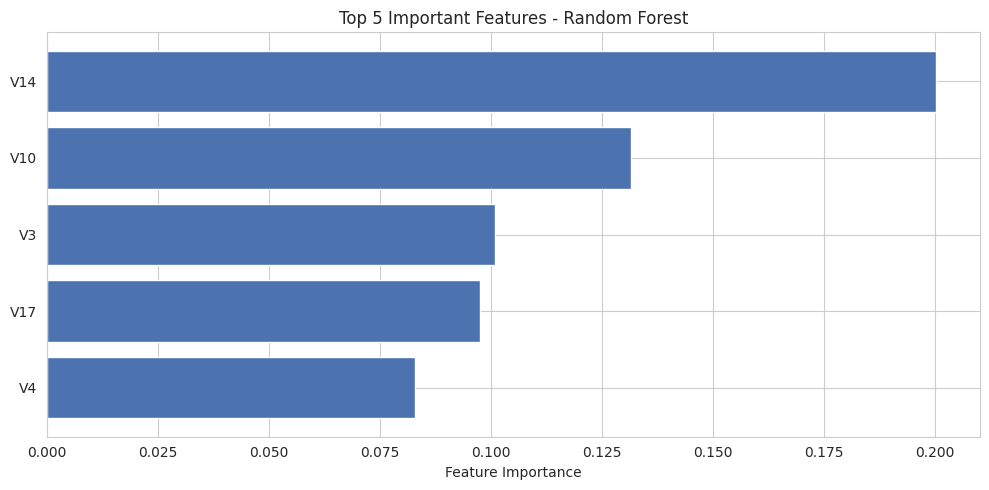

In [45]:
#Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train_res, y_train_res)
fitted_models["Random Forest"] = rf
_ = evaluate_model("Random Forest", rf, X_test, y_test)
_ = plot_top_features("Random Forest", rf, X.columns)


--- XGBoost ---
Accuracy: 0.9992
ROC AUC: 0.9943

Classification Report:

              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00     13057
       Fraud       0.79      0.91      0.85        34

    accuracy                           1.00     13091
   macro avg       0.90      0.96      0.92     13091
weighted avg       1.00      1.00      1.00     13091



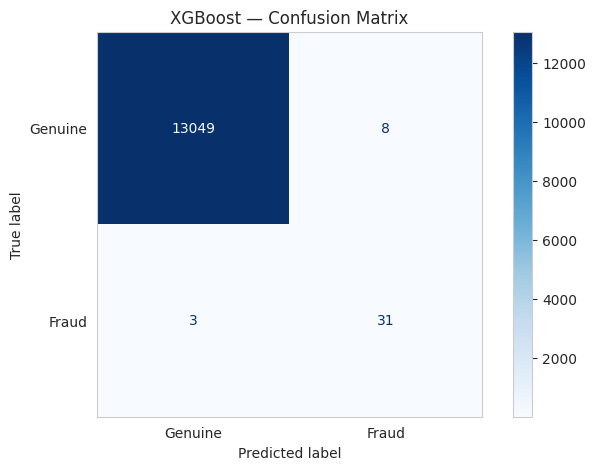

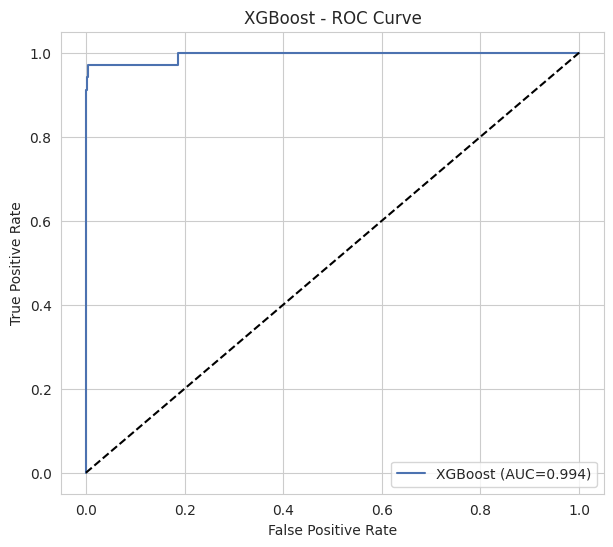

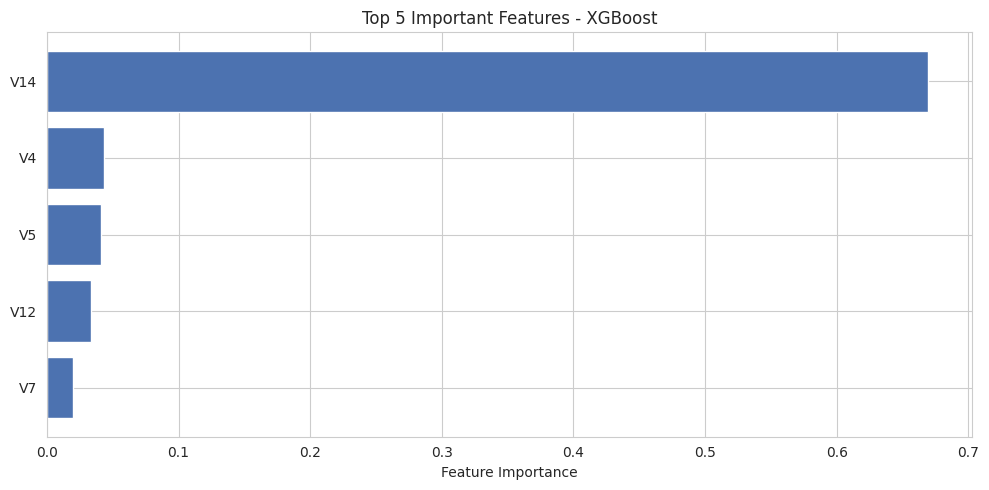

In [46]:
# XGBoost
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
)
xgb.fit(X_train_res, y_train_res)
fitted_models["XGBoost"] = xgb
_ = evaluate_model("XGBoost", xgb, X_test, y_test)
_ = plot_top_features("XGBoost", xgb, X.columns)


[LightGBM] [Info] Number of positive: 52226, number of negative: 52226
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.029284 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 104452, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

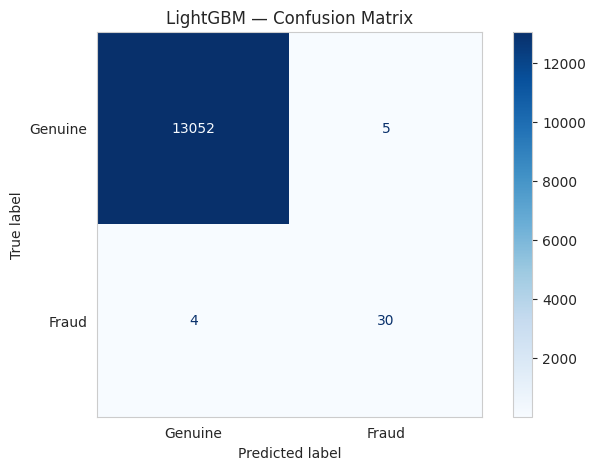

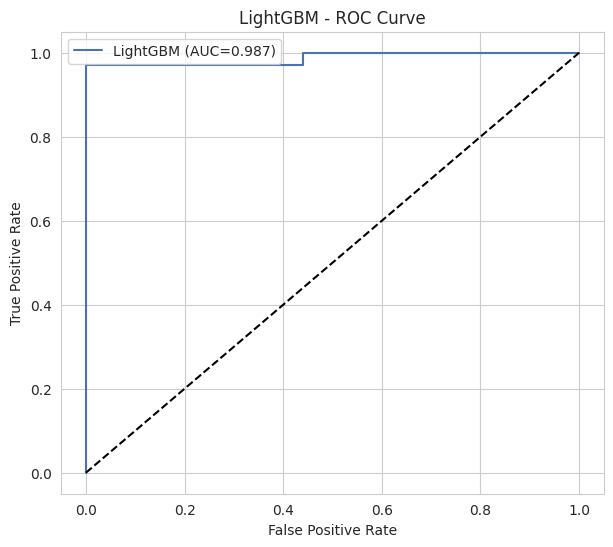

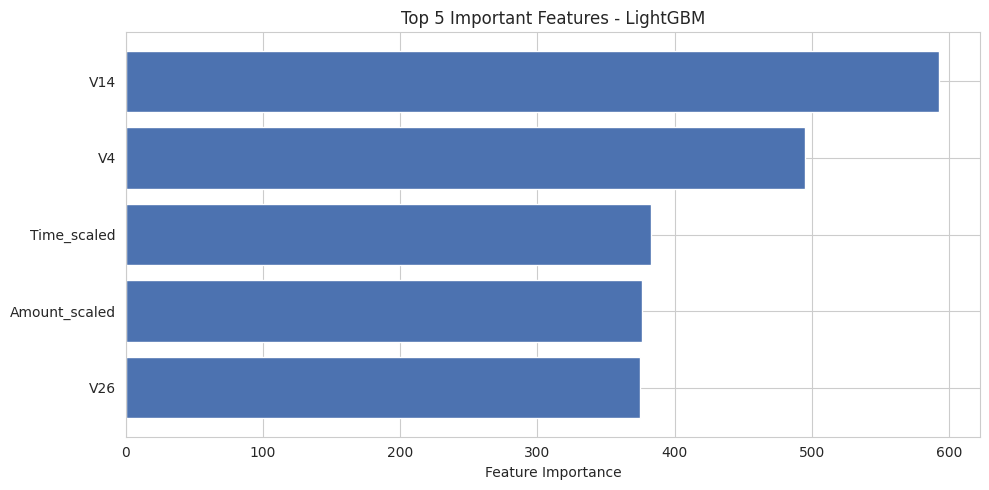

In [47]:
# LightGBM
lgbm = LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    random_state=RANDOM_STATE, n_jobs=-1
)
lgbm.fit(X_train_res, y_train_res)
fitted_models["LightGBM"] = lgbm
_ = evaluate_model("LightGBM", lgbm, X_test, y_test)
_ = plot_top_features("LightGBM", lgbm, X.columns)


## Compare all models

               Accuracy  Precision    Recall  F1-score   ROC-AUC    PR-AUC
XGBoost        0.999160   0.794872  0.911765  0.849315  0.994278  0.929477
LightGBM       0.999313   0.857143  0.882353  0.869565  0.986973  0.947960
Random Forest  0.999465   0.885714  0.911765  0.898551  0.982558  0.938798


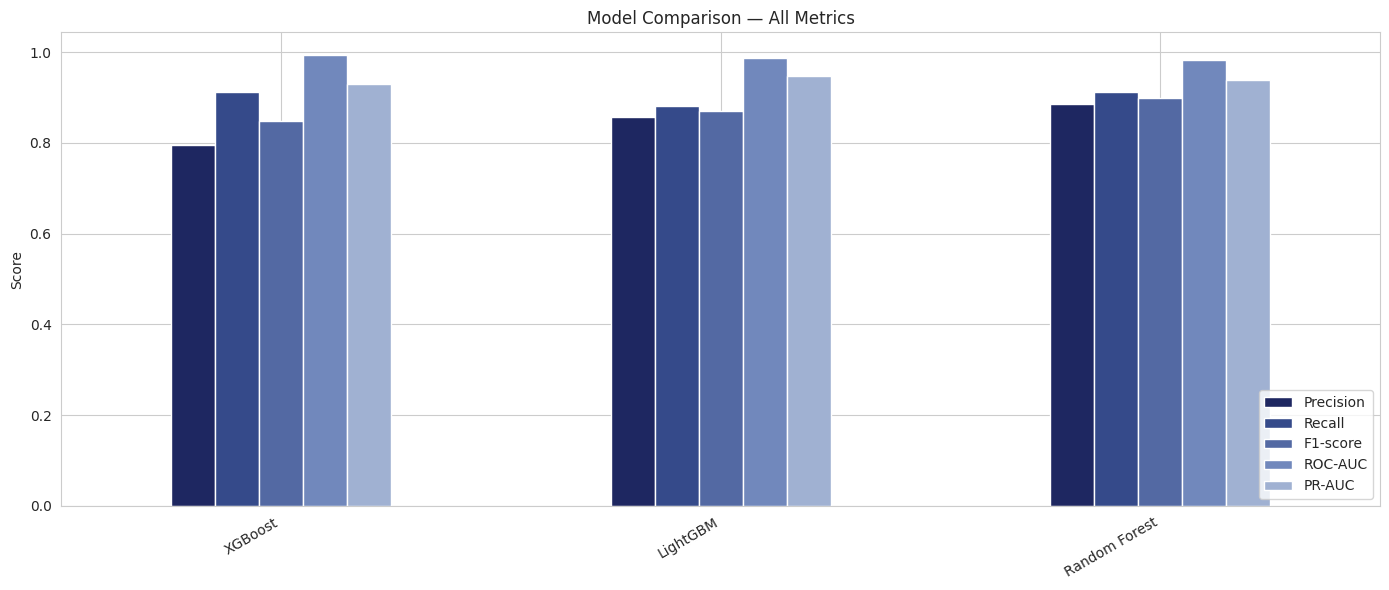

In [48]:
results_df = pd.DataFrame(results).T.sort_values("ROC-AUC", ascending=False)
print(results_df)

colors = ["#1E2761", "#354A8A", "#5369A3", "#7188BC", "#A0B1D2"]

ax = results_df[["Precision", "Recall", "F1-score", "ROC-AUC", "PR-AUC"]].plot(
    kind="bar",
    figsize=(14, 6),
    color=colors
)

plt.title("Model Comparison — All Metrics")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.legend(loc="lower right")

plt.tight_layout()

# Download/save high-quality figure
plt.savefig(
    "model_comparison_all_metrics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


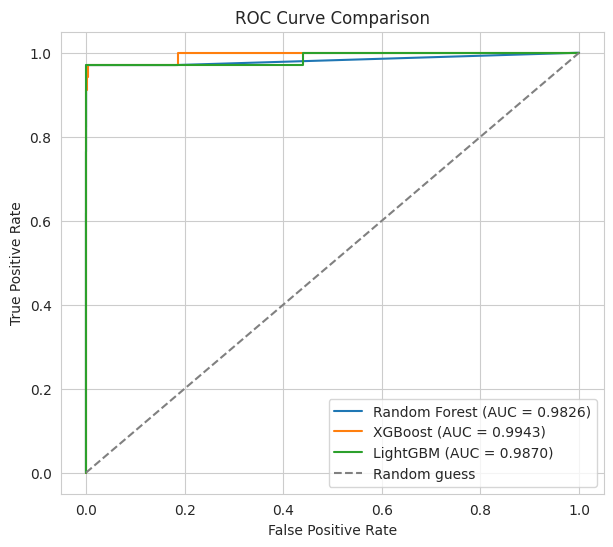

In [49]:
plt.figure(figsize=(7, 6))
for name, (fpr, tpr, auc_score) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.savefig(
    "roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


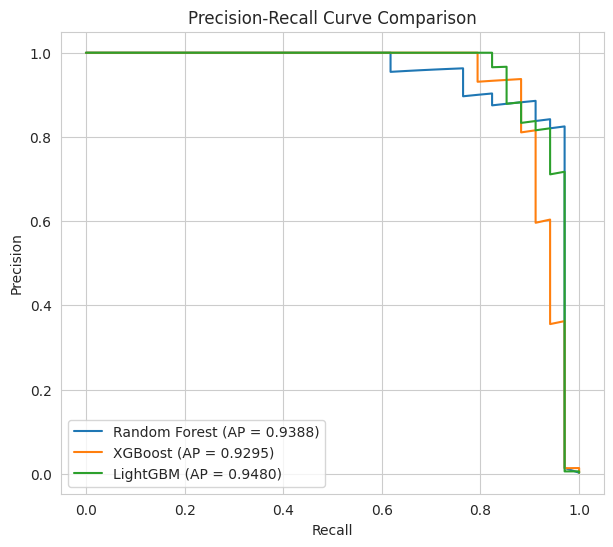

In [50]:
plt.figure(figsize=(7, 6))
for name, (prec, rec, ap_score) in pr_data.items():
    plt.plot(rec, prec, label=f"{name} (AP = {ap_score:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.savefig(
    "pr_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


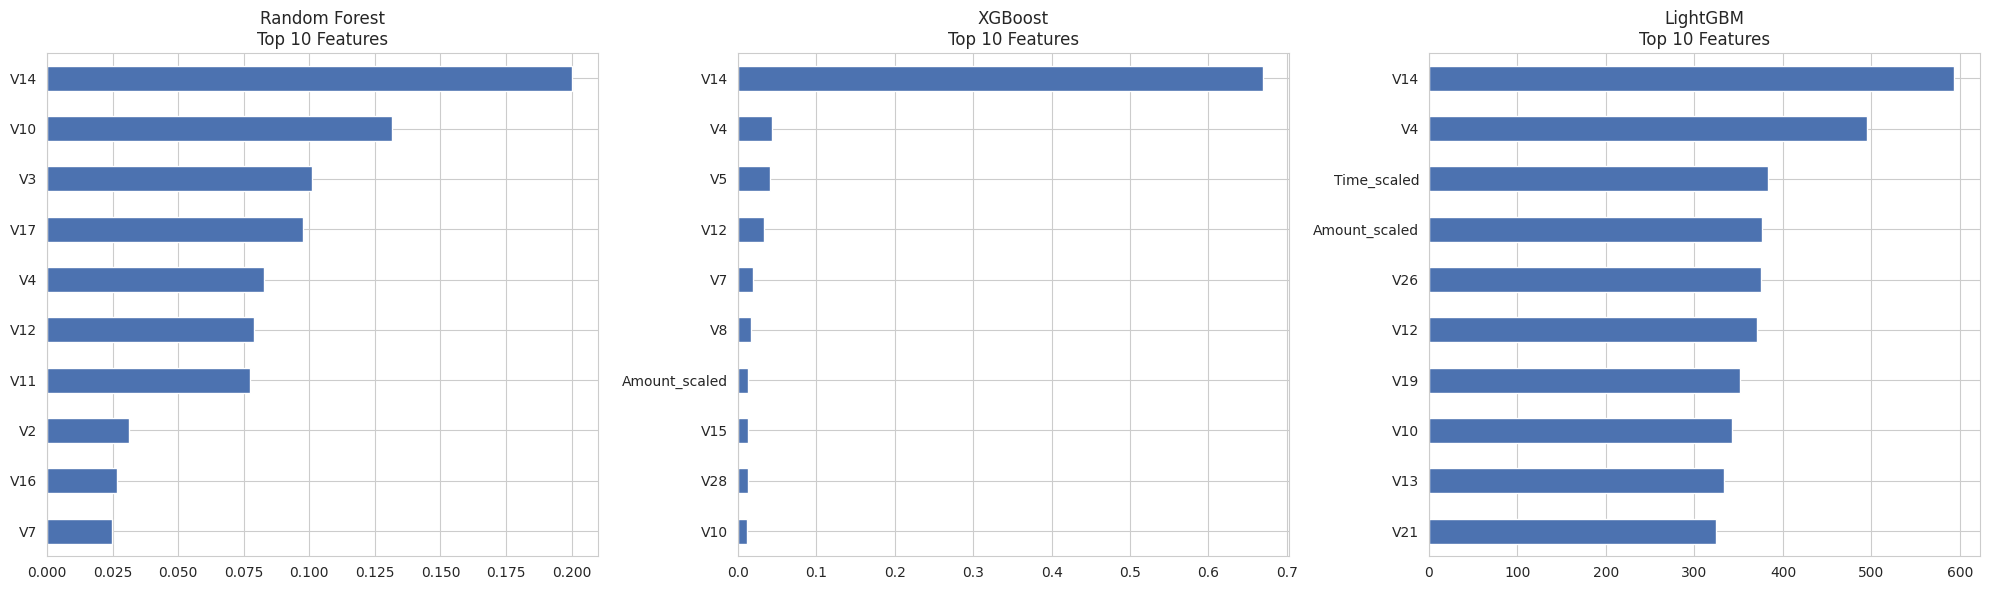

In [51]:
tree_models = {
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm,
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, model) in zip(axes, tree_models.items()):
    importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    importances.plot(kind="barh", ax=ax, color="#4C72B0")
    ax.invert_yaxis()
    ax.set_title(f"{name}\nTop 10 Features")
plt.tight_layout()
plt.show()


Best model based on ROC-AUC: XGBoost


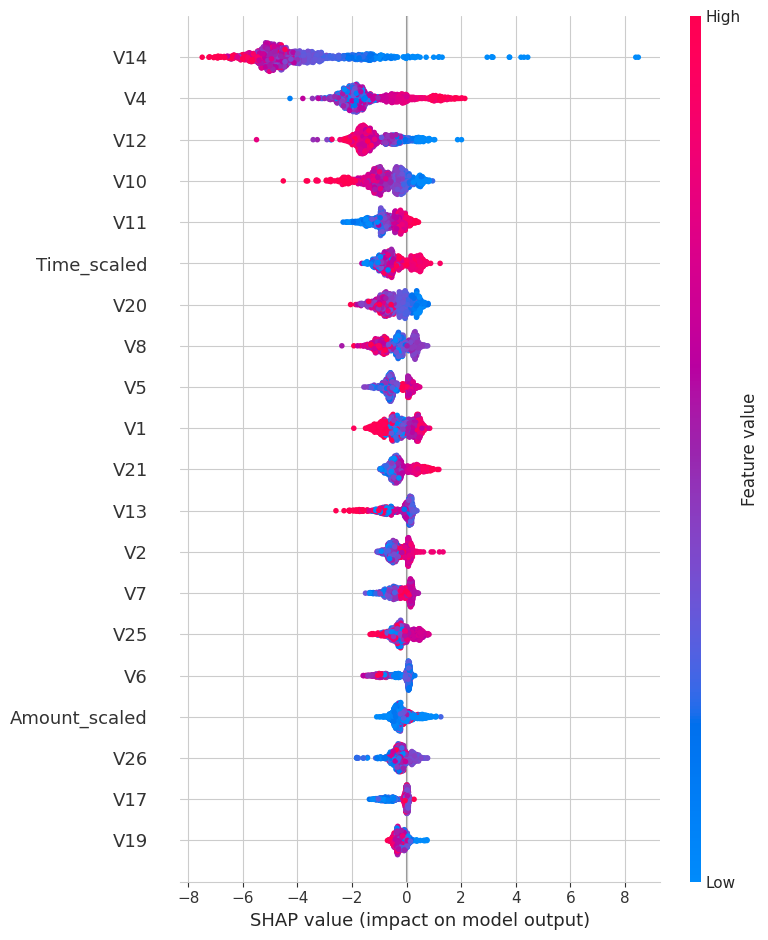

In [52]:
best_model_name = results_df["ROC-AUC"].idxmax()
best_model = fitted_models[best_model_name]
print(f"Best model based on ROC-AUC: {best_model_name}")

# SHAP explains individual predictions in terms of feature contributions.
explainer = shap.TreeExplainer(best_model)
shap_sample = X_test.sample(1000, random_state=RANDOM_STATE)  # sample for speed
shap_values = explainer.shap_values(shap_sample)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values
shap.summary_plot(sv, shap_sample, show=True)


## Save the best model

In [53]:
joblib.dump(best_model, "/content/best_fraud_model.pkl")
joblib.dump(amount_scaler, "/content/amount_scaler.pkl")
joblib.dump(time_scaler, "/content/time_scaler.pkl")


['/content/time_scaler.pkl']

## Simulate a real-time transaction stream


In [54]:
def simulate_stream(model, X_stream, y_stream, threshold=0.5, delay_seconds=0.05, n_transactions=200):
    """Replay `n_transactions` rows one at a time, predicting fraud probability for each."""
    stream_X = X_stream.iloc[:n_transactions].reset_index(drop=True)
    stream_y = y_stream.iloc[:n_transactions].reset_index(drop=True)

    log = []
    for i in range(len(stream_X)):
        row = stream_X.iloc[[i]]

        start = time.time()
        prob = model.predict_proba(row)[0, 1]
        elapsed = time.time() - start

        flagged = prob >= threshold
        log.append({
            "transaction_id": i,
            "fraud_probability": prob,
            "flagged_suspicious": flagged,
            "actual_label": stream_y.iloc[i],
            "processing_time_ms": elapsed * 1000,
        })

        if flagged:
            print(f"[t={i:04d}] ALERT: suspicious transaction, "
                  f"fraud probability = {prob:.4f} (actual label = {stream_y.iloc[i]})")

        time.sleep(delay_seconds)  # simulate transactions arriving over time

    return pd.DataFrame(log)

loaded_model = joblib.load("/content/best_fraud_model.pkl")
stream_log = simulate_stream(loaded_model, X_test, y_test, threshold=0.5,
                              delay_seconds=0.02, n_transactions=200)


### Extract Raw Values from a Fraudulent Test Transaction

In [55]:
fraud_sample = X_test[y_test == 1].iloc[0]

fraud_index = fraud_sample.name

raw_values = df.loc[fraud_index, ["Amount", "Time"]]

raw_values


,42936
Amount,59.68
Time,41305.00


### Preparing a Transaction Payload for Real-Time Fraud Prediction in Azure Function

In [56]:


payload = fraud_sample.drop(
    ["Amount_scaled", "Time_scaled"]
).to_dict()

payload["Amount"] = float(raw_values["Amount"])
payload["Time"] = float(raw_values["Time"])

print(json.dumps(payload, indent=2))

{
  "V1": -12.9809425647533,
  "V2": 6.72050777097643,
  "V3": -13.4556359425571,
  "V4": 8.69861009281133,
  "V5": -11.4795517833437,
  "V6": -2.68151865053833,
  "V7": -14.0192907576919,
  "V8": 8.21819051252864,
  "V9": -7.93089996826719,
  "V10": -12.6959474039839,
  "V11": 5.58936163192341,
  "V12": -11.9608660326622,
  "V13": 1.53867076186333,
  "V14": -9.88721406724695,
  "V15": 0.6339792179337,
  "V16": -11.3502438549644,
  "V17": -21.7101876525534,
  "V18": -8.85945192496352,
  "V19": 3.62971365041526,
  "V20": -0.84330261969681,
  "V21": 2.54962823474498,
  "V22": -0.532227763596568,
  "V23": -0.235096473604284,
  "V24": 0.673209169467055,
  "V25": 0.22659797207791,
  "V26": -0.0061678581900246,
  "V27": -1.18569550568181,
  "V28": -0.747361321404312,
  "Amount": 59.68,
  "Time": 41305.0
}
